<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica4Quest%C3%A3o1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- DFT com N = 4 (mostrando apenas os primeiros pontos) ---
X[0] = 0.0000+0.0000j   (|X[0]| = 0.0000, fase = 0.0000 rad)
X[1] = 0.0000-0.0000j   (|X[1]| = 0.0000, fase = -0.7854 rad)
X[2] = 4.0000+0.0000j   (|X[2]| = 4.0000, fase = 0.0000 rad)
X[3] = -0.0000-0.0000j   (|X[3]| = 0.0000, fase = -2.3562 rad)

--- DFT com N = 16 (mostrando apenas os primeiros pontos) ---
X[0] = 0.0000+0.0000j   (|X[0]| = 0.0000, fase = 0.0000 rad)
X[1] = 0.4005+0.5995j   (|X[1]| = 0.7210, fase = 0.9817 rad)
X[2] = 1.0000+0.4142j   (|X[2]| = 1.0824, fase = 0.3927 rad)
X[3] = 0.8341-0.1659j   (|X[3]| = 0.8504, fase = -0.1963 rad)
X[4] = 0.0000-0.0000j   (|X[4]| = 0.0000, fase = -0.7854 rad)
X[5] = -0.2483+1.2483j   (|X[5]| = 1.2728, fase = 1.7671 rad)
X[6] = 1.0000+2.4142j   (|X[6]| = 2.6131, fase = 1.1781 rad)
X[7] = 3.0137+2.0137j   (|X[7]| = 3.6245, fase = 0.5890 rad)
...

--- DFT com N = 64 (mostrando apenas os primeiros pontos) ---
X[0] = 0.0000+0.0000j   (|X[0]| = 0.0000, fase = 0.0000 rad)
X[1] = 0.

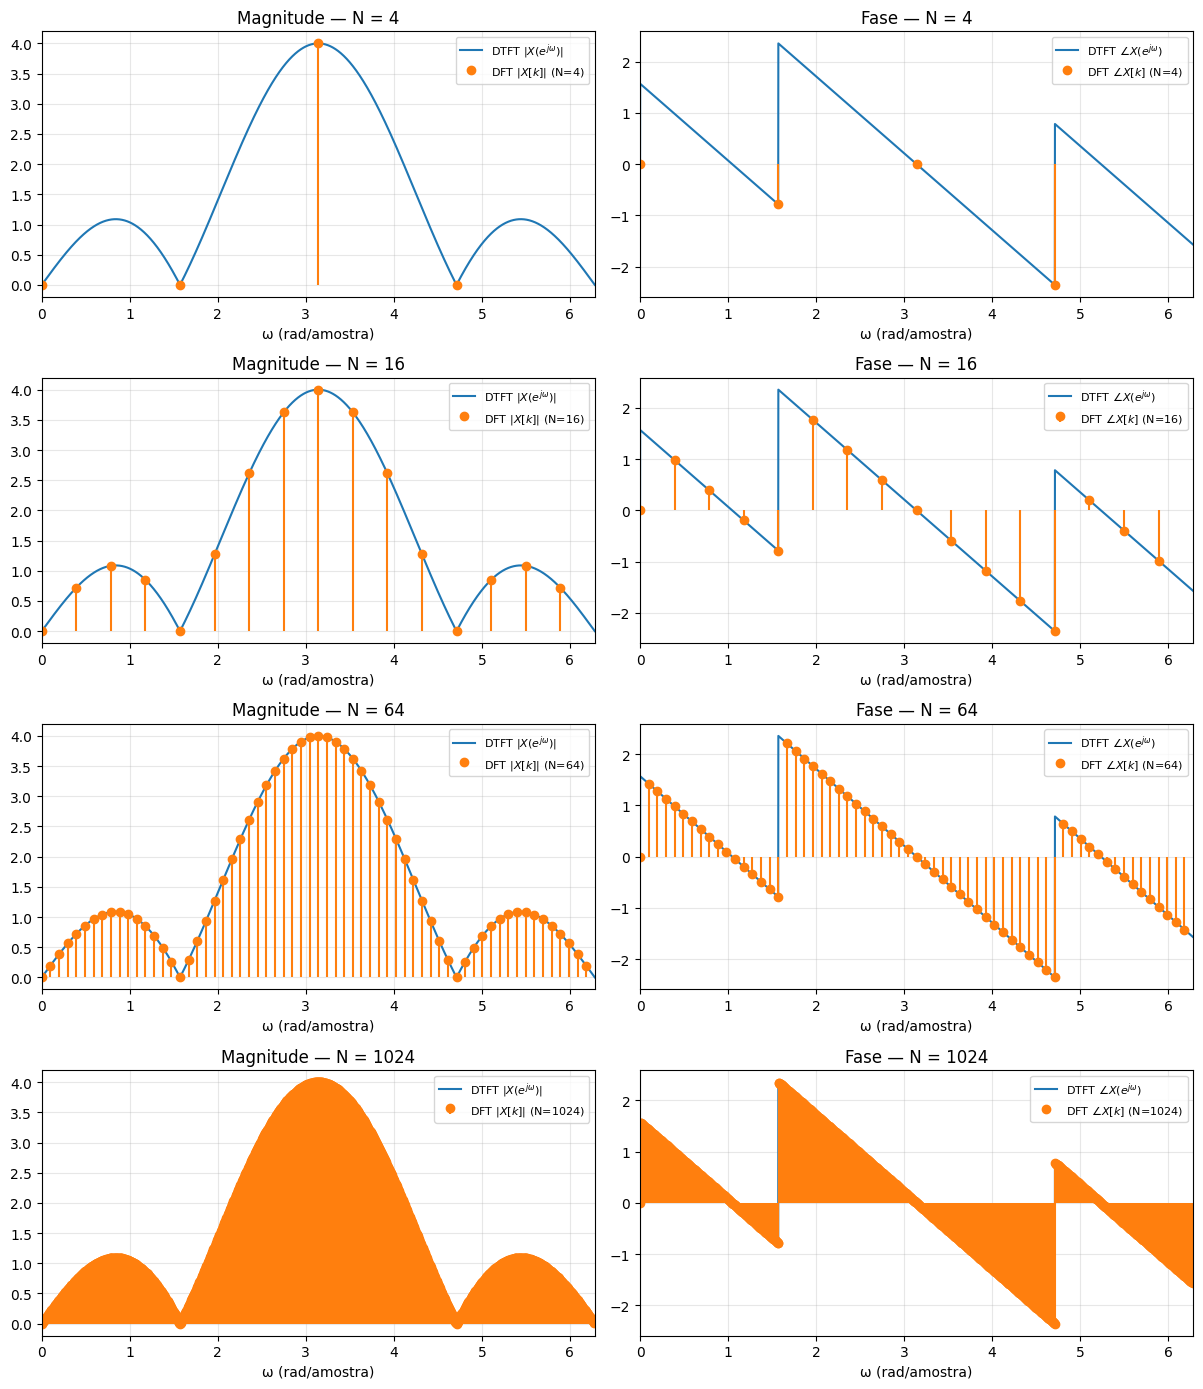

In [2]:

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Definição do sinal x[n]
# ---------------------------------------------------------------------------
# x[n] = δ[n] - δ[n-1] + δ[n-2] - δ[n-3]  ->  x[0]=1, x[1]=-1, x[2]=1, x[3]=-1
x = np.array([1, -1, 1, -1], dtype=complex)


# ---------------------------------------------------------------------------
# 2. Matriz de DFT e cálculo da DFT (sem usar fft)
# ---------------------------------------------------------------------------
def matriz_dft(N):
    """
    Constrói a matriz de DFT de tamanho N x N:

        W[k, n] = exp(-j * 2*pi * k * n / N),   0 <= k, n <= N-1
    """
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-1j * 2 * np.pi * k * n / N)
    return W


def calcula_dft(x, N):
    """
    Calcula a DFT de N pontos do sinal x através do produto matricial

        X = W @ x_padded

    Se N > len(x), o sinal é completado com zeros (zero-padding) antes
    da multiplicação pela matriz de DFT.
    """
    if N < len(x):
        raise ValueError("N deve ser maior ou igual ao comprimento de x[n].")

    x_padded = np.zeros(N, dtype=complex)
    x_padded[: len(x)] = x

    W = matriz_dft(N)
    X = W @ x_padded
    return X


# ---------------------------------------------------------------------------
# 3. DTFT (calculada por somatório direto, também sem fft)
# ---------------------------------------------------------------------------
def calcula_dtft(x, w):
    """
    Calcula a DTFT de x[n] avaliada em um vetor de frequências w (rad/amostra):

        X(e^jw) = soma_n x[n] * exp(-j*w*n)
    """
    n = np.arange(len(x))
    X = np.array([np.sum(x * np.exp(-1j * wi * n)) for wi in w])
    return X


# Grade fina de frequências em [0, 2*pi) para representar a DTFT "contínua"
w = np.linspace(0, 2 * np.pi, 4000)
Xw = calcula_dtft(x, w)

# ---------------------------------------------------------------------------
# 4. Cálculo da DFT para N = 4, 16, 64, 1024 e comparação com a DTFT
# ---------------------------------------------------------------------------
valores_N = [4, 16, 64, 1024]

fig, axes = plt.subplots(len(valores_N), 2, figsize=(12, 14))

for i, N in enumerate(valores_N):
    X = calcula_dft(x, N)
    wk = 2 * np.pi * np.arange(N) / N  # frequências discretas da DFT

    # ----- Magnitude -----
    axes[i, 0].plot(w, np.abs(Xw), color="C0", label="DTFT $|X(e^{j\\omega})|$")
    axes[i, 0].stem(
        wk, np.abs(X), linefmt="C1-", markerfmt="C1o", basefmt=" ",
        label=f"DFT $|X[k]|$ (N={N})",
    )
    axes[i, 0].set_title(f"Magnitude — N = {N}")
    axes[i, 0].set_xlabel("ω (rad/amostra)")
    axes[i, 0].set_xlim(0, 2 * np.pi)
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].grid(True, alpha=0.3)

    # ----- Fase -----
    axes[i, 1].plot(w, np.angle(Xw), color="C0", label="DTFT $\\angle X(e^{j\\omega})$")
    axes[i, 1].stem(
        wk, np.angle(X), linefmt="C1-", markerfmt="C1o", basefmt=" ",
        label=f"DFT $\\angle X[k]$ (N={N})",
    )
    axes[i, 1].set_title(f"Fase — N = {N}")
    axes[i, 1].set_xlabel("ω (rad/amostra)")
    axes[i, 1].set_xlim(0, 2 * np.pi)
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(True, alpha=0.3)

    # Imprime os valores numéricos da DFT no terminal
    print(f"\n--- DFT com N = {N} (mostrando apenas os primeiros pontos) ---")
    for k in range(min(N, 8)):
        print(f"X[{k}] = {X[k]:.4f}   (|X[{k}]| = {abs(X[k]):.4f}, "
              f"fase = {np.angle(X[k]):.4f} rad)")
    if N > 8:
        print("...")

plt.tight_layout()
plt.savefig("dft_vs_dtft.png", dpi=150)
plt.show()
